# 07 - Efficiency Comparison

Goal: compare CNN and hybrid models using accuracy, macro-F1, parameter count, token count, and inference latency on the same Salinas batch.

In [1]:
from pathlib import Path
import sys
import time

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from dfm.data.salinas import (
    SALINAS_CLASS_NAMES,
    SalinasPatchDataset,
    labeled_pixel_indices,
    load_salinas,
    stratified_train_test_split,
)
from dfm.experiments.token_scaling import attention_cost_proxy, independent_band_tokens
from dfm.models.cnn_baseline import CNNBaseline
from dfm.models.hybrid import HybridSpatialSpectralClassifier
from dfm.training.profiling import count_parameters

In [2]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

outputs_dir = PROJECT_ROOT / "outputs" / "salinas"
data_dir = PROJECT_ROOT / "data" / "raw" / "salinas"

scene = load_salinas(data_dir, download=False)
rows, cols, labels = labeled_pixel_indices(scene.labels)
train_indices, test_indices = stratified_train_test_split(labels, train_fraction=0.1, seed=SEED)

patch_size = 15
test_dataset = SalinasPatchDataset(scene, indices=test_indices, patch_size=patch_size)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)
batch_x, batch_y = next(iter(test_loader))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_x = batch_x.to(device=device, dtype=torch.float32)

print("Device:", device)
print("Batch:", batch_x.shape)
print("Bands:", scene.bands)

Device: cpu
Batch: torch.Size([256, 204, 15, 15])
Bands: 204


In [3]:
def load_checkpoint(path):
    if not path.exists():
        return None
    return torch.load(path, map_location=device)


cnn_model = CNNBaseline(
    in_channels=scene.bands,
    num_classes=len(SALINAS_CLASS_NAMES),
    hidden_channels=64,
    dropout=0.1,
).to(device)
cnn_ckpt = load_checkpoint(outputs_dir / "cnn_baseline_best.pt")
if cnn_ckpt is not None:
    cnn_model.load_state_dict(cnn_ckpt["model_state_dict"])

hybrid_model = HybridSpatialSpectralClassifier(
    in_channels=scene.bands,
    num_classes=len(SALINAS_CLASS_NAMES),
    feature_dim=128,
    spectral_depth=2,
    spectral_heads=4,
    fusion="gated",
    dropout=0.1,
    max_bands=256,
).to(device)
hybrid_ckpt = load_checkpoint(outputs_dir / "hybrid_baseline_best.pt")
if hybrid_ckpt is not None:
    hybrid_model.load_state_dict(hybrid_ckpt["model_state_dict"])

print("CNN checkpoint loaded:", cnn_ckpt is not None)
print("Hybrid checkpoint loaded:", hybrid_ckpt is not None)

CNN checkpoint loaded: False
Hybrid checkpoint loaded: True


In [4]:
@torch.no_grad()
def measure_latency(model, x, warmup=5, repeats=30):
    model.eval()
    for _ in range(warmup):
        _ = model(x)
    if x.is_cuda:
        torch.cuda.synchronize()

    start = time.perf_counter()
    for _ in range(repeats):
        _ = model(x)
    if x.is_cuda:
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start
    return elapsed / repeats


def best_metrics(history_path):
    history = pd.read_csv(history_path)
    best = history.loc[history["macro_f1"].idxmax()]
    return int(best["epoch"]), float(best["accuracy"]), float(best["macro_f1"])

In [5]:
rows_out = []

for name, model, history_name in [
    ("CNN baseline", cnn_model, "cnn_baseline_history.csv"),
    ("Hybrid spatial-spectral", hybrid_model, "hybrid_baseline_history.csv"),
]:
    best_epoch, accuracy, macro_f1 = best_metrics(outputs_dir / history_name)
    latency_s = measure_latency(model, batch_x)
    rows_out.append({
        "model": name,
        "best_epoch": best_epoch,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "parameters": count_parameters(model),
        "batch_size": int(batch_x.shape[0]),
        "latency_ms_per_batch": latency_s * 1000.0,
        "latency_ms_per_sample": latency_s * 1000.0 / batch_x.shape[0],
    })

comparison_df = pd.DataFrame(rows_out)
comparison_df.to_csv(outputs_dir / "efficiency_comparison.csv", index=False)
comparison_df

,model,best_epoch,accuracy,macro_f1,parameters,batch_size,latency_ms_per_batch,latency_ms_per_sample
0,CNN baseline,4,0.948249,0.974376,126480,256,95.192180,0.371844
1,Hybrid spatial-spectral,3,0.973334,0.979062,605712,256,622.945623,2.433381


## Token Cost Context

The CNN and hybrid models do not use independent band-patch full attention. The table below shows what the independent-band transformer sequence length would look like for the same Salinas patch.

In [6]:
token_rows = []
for transformer_patch_size in [1, 3, 5, 15]:
    tokens = independent_band_tokens(
        height=patch_size,
        width=patch_size,
        bands=scene.bands,
        patch_size=transformer_patch_size,
    )
    token_rows.append({
        "transformer_patch_size": transformer_patch_size,
        "bands": scene.bands,
        "tokens": tokens,
        "attention_cost_proxy": attention_cost_proxy(tokens),
    })

token_df = pd.DataFrame(token_rows)
token_df.to_csv(outputs_dir / "salinas_patch_token_cost_context.csv", index=False)
token_df

,transformer_patch_size,bands,tokens,attention_cost_proxy
0,1,204,45900,2106810000
1,3,204,5100,26010000
2,5,204,1836,3370896
3,15,204,204,41616


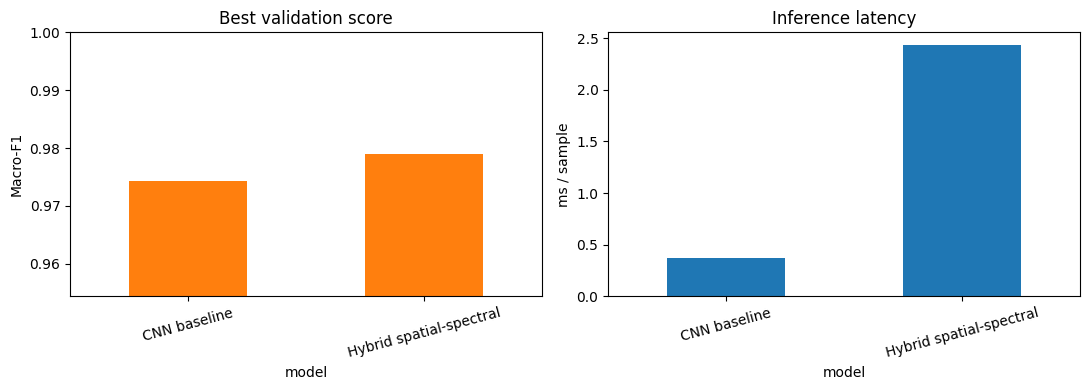

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

comparison_df.plot.bar(x="model", y="macro_f1", ax=axes[0], legend=False, color="tab:orange")
axes[0].set_ylim(max(0.0, comparison_df["macro_f1"].min() - 0.02), 1.0)
axes[0].set_ylabel("Macro-F1")
axes[0].set_title("Best validation score")
axes[0].tick_params(axis="x", rotation=15)

comparison_df.plot.bar(x="model", y="latency_ms_per_sample", ax=axes[1], legend=False, color="tab:blue")
axes[1].set_ylabel("ms / sample")
axes[1].set_title("Inference latency")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(outputs_dir / "efficiency_comparison.png", dpi=200);